# DEAM Dataset Audit and Labels

This notebook loads DEAM static and dynamic annotations, checks data completeness, builds a clean metadata table, and visualizes valence/arousal distributions.

**Prerequisites:** Download the DEAM dataset and place it under `data/raw/DEAM/` (see project README). All paths are configured in `configs/paths.yaml`.

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Ensure project root is on the Python path when running from notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "configs").exists() and (PROJECT_ROOT.parent / "configs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_configs, resolve_path
from src.data.load_deam import (
    audit_deam_dataset,
    build_metadata_table,
    load_dynamic_annotations,
    load_static_annotations,
    save_metadata_table,
)
from src.data.make_static_dataset import build_static_label_dataset, save_static_dataset, summarize_static_labels
from src.data.make_dynamic_dataset import (
    build_dynamic_window_dataset,
    build_dynamic_trajectory_summary,
    save_dynamic_dataset,
    save_dynamic_trajectory_summary,
)
from src.visualization.plots import (
    plot_data_completeness,
    plot_valence_arousal_distributions,
    plot_valence_arousal_scatter,
)

configs = load_configs(PROJECT_ROOT)
root = get_project_root(PROJECT_ROOT)
print(f"Project root: {root}")

Project root: C:\Users\athen\Desktop\music-emotion-recognition


## 1. Load annotations

In [2]:
static_df = load_static_annotations(configs)
dynamic_df = load_dynamic_annotations(configs)

print(f"Static tracks: {len(static_df)}")
print(f"Dynamic annotation rows: {len(dynamic_df)}")
print(f"Dynamic tracks: {dynamic_df['song_id'].nunique()}")

static_df.head()

Static tracks: 1802
Dynamic annotation rows: 129995
Dynamic tracks: 1802


,song_id,valence,arousal
0,2,3.1,3.0
1,3,3.5,3.3
2,4,5.7,5.5
3,5,4.4,5.3
4,7,5.8,6.4


## 2. Audit dataset completeness

In [3]:
audit = audit_deam_dataset(configs)
metadata = audit["metadata"]

summary_rows = {k: v for k, v in audit.items() if k != "metadata"}
pd.Series(summary_rows).to_frame("value")

Scanning audio files:   0%|          | 0/1802 [00:00<?, ?it/s]

,value
n_tracks_static,1802.000000
n_tracks_with_audio,1802.000000
n_tracks_with_dynamic,1802.000000
n_tracks_complete,1802.000000
n_missing_static_valence,0.000000
n_missing_static_arousal,0.000000
n_missing_audio,0.000000
n_missing_dynamic,0.000000
valence_mean,4.904145
valence_std,1.174240


In [4]:
missing_audio = metadata.loc[~metadata["has_audio"], "song_id"].tolist()
missing_dynamic = metadata.loc[~metadata["has_dynamic_annotation"], "song_id"].tolist()

print(f"Tracks missing audio: {len(missing_audio)}")
print(f"Tracks missing dynamic annotations: {len(missing_dynamic)}")

metadata.head(10)

Tracks missing audio: 0
Tracks missing dynamic annotations: 0


,song_id,valence,arousal,has_static_annotation,has_dynamic_annotation,has_audio,audio_path,n_dynamic_samples,is_complete
0,2,3.1,3.0,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
1,3,3.5,3.3,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
2,4,5.7,5.5,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
3,5,4.4,5.3,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
4,7,5.8,6.4,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
5,8,3.2,4.8,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
6,10,4.0,4.7,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
7,12,5.5,5.8,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
8,13,3.2,4.0,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True
9,17,4.4,6.0,True,True,True,C:\Users\athen\Desktop\music-emotion-recogniti...,60,True


## 3. Save clean metadata table

In [5]:
saved_paths = save_metadata_table(metadata, configs)
saved_paths

{'csv': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/data/processed/deam_metadata.csv'),
 'parquet': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/data/processed/deam_metadata.parquet')}

## 4. Basic valence / arousal statistics

In [6]:
metadata[["valence", "arousal"]].describe()

,valence,arousal
count,1802.000000,1802.000000
mean,4.904145,4.814029
std,1.174240,1.282187
min,1.600000,1.600000
25%,4.100000,3.800000
50%,4.900000,4.900000
75%,5.800000,5.800000
max,8.400000,8.100000


## 5. Visualizations

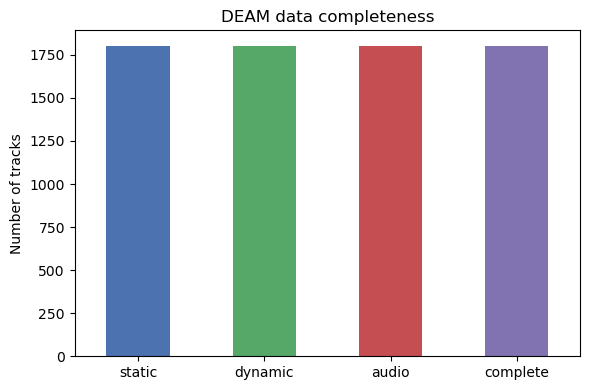

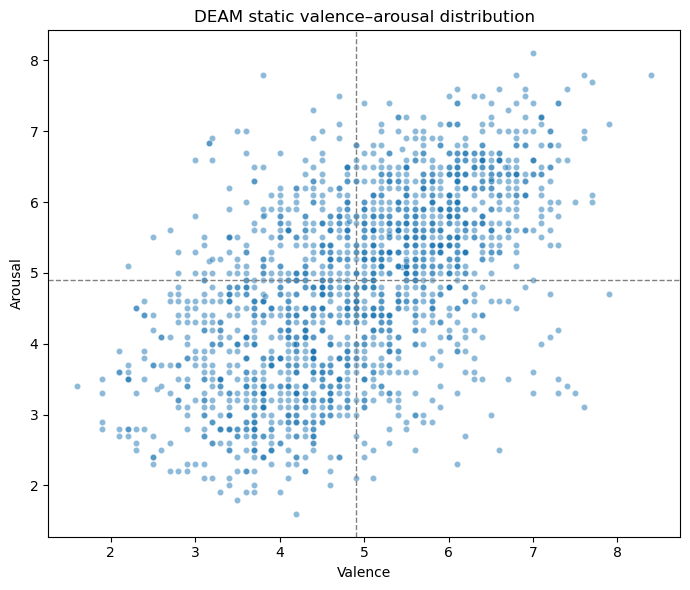

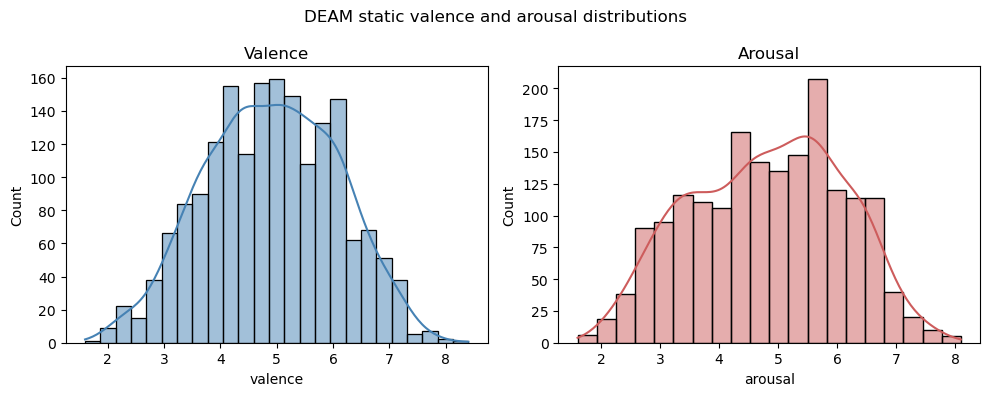

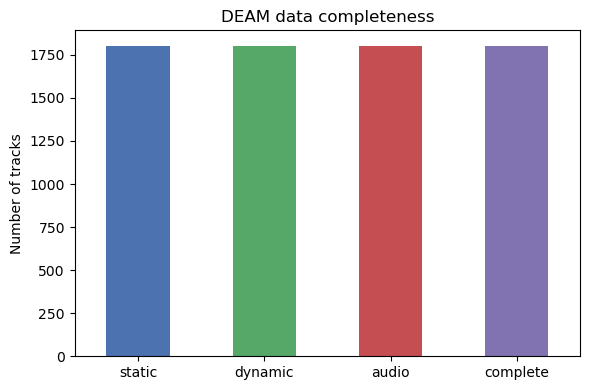

In [7]:
figures_dir = resolve_path(root, configs["paths"]["reports"]["figures"])

plot_valence_arousal_scatter(
    metadata,
    output_path=figures_dir / "deam_valence_arousal_scatter.png",
)
plot_valence_arousal_distributions(
    metadata,
    output_path=figures_dir / "deam_valence_arousal_distributions.png",
)
plot_data_completeness(
    metadata,
    output_path=figures_dir / "deam_data_completeness.png",
)

## 6. Build static and dynamic label tables (preview)

These tables will be used in later notebooks for feature extraction and model training.

In [8]:
static_labels = build_static_label_dataset(metadata, configs)
static_summary = summarize_static_labels(static_labels)

print(f"Static label tracks (complete only): {len(static_labels)}")
static_summary

Static label tracks (complete only): 1802


,emotion_quadrant,count,proportion,emotion_class
0,Q1,679,0.376804,high_valence_high_arousal
1,Q2,251,0.139290,high_valence_low_arousal
2,Q3,234,0.129856,low_valence_high_arousal
3,Q4,638,0.354051,low_valence_low_arousal


In [9]:
save_static_dataset(static_labels, configs)

dynamic_windows = build_dynamic_window_dataset(metadata, dynamic_df, configs)
trajectory_summary = build_dynamic_trajectory_summary(dynamic_df, configs)

print(f"Dynamic windows: {len(dynamic_windows)}")
print(f"Stable tracks (no emotion transitions): {trajectory_summary['is_stable'].sum()}")

dynamic_windows.head()

Building dynamic windows:   0%|          | 0/1802 [00:00<?, ?it/s]

Dynamic windows: 129995
Stable tracks (no emotion transitions): 1270


,track_id,window_start,window_end,window_index,valence,arousal,emotion_quadrant,dynamic_emotion_class,valence_threshold,arousal_threshold
0,2,14.5,15.5,29,-0.073341,-0.109386,Q4,low_valence_low_arousal,0.095,0.133338
1,2,15.0,16.0,30,-0.074001,-0.112164,Q4,low_valence_low_arousal,0.095,0.133338
2,2,15.5,16.5,31,-0.074369,-0.115677,Q4,low_valence_low_arousal,0.095,0.133338
3,2,16.0,17.0,32,-0.076115,-0.117513,Q4,low_valence_low_arousal,0.095,0.133338
4,2,16.5,17.5,33,-0.079871,-0.122535,Q4,low_valence_low_arousal,0.095,0.133338


In [10]:
save_dynamic_dataset(dynamic_windows, configs)
save_dynamic_trajectory_summary(trajectory_summary, configs)

WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/data/processed/dynamic_trajectories.parquet')